In [1]:
# Cell 0: Install missing packages (run once)
import subprocess
import sys

packages = ['ta', 'textblob', 'newsapi-python', 'scikit-learn']

for package in packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"✅ {package} already installed")
    except ImportError:
        print(f"📦 Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✅ {package} installed")

# Also install talib (might need special handling)
try:
    import talib
    print("✅ TA-Lib already installed")
except:
    print("⚠️ TA-Lib requires separate installation")
    print("   Run: conda install -c conda-forge ta-lib")
    
print("\n✅ All packages ready!")

✅ ta already installed
✅ textblob already installed
📦 Installing newsapi-python...
✅ newsapi-python installed
📦 Installing scikit-learn...
✅ scikit-learn installed
✅ TA-Lib already installed

✅ All packages ready!


In [2]:
# Cell 1: Imports and Setup
import sys
import os
import pandas as pd
import numpy as np
import yfinance as yf
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Technical indicators (using 'ta' package instead of talib)
from ta import add_all_ta_features
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD, EMAIndicator, SMAIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator

# Feature selection
from sklearn.feature_selection import mutual_info_regression, RFE, SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Sentiment
from textblob import TextBlob
import requests

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set paths
sys.path.append('..')
DATA_PATH = Path('../../data/processed/sp500_processed.csv')
FEATURES_PATH = Path('../../data/features')
FEATURES_PATH.mkdir(parents=True, exist_ok=True)

print("✅ All imports loaded successfully")
print(f"📁 Features directory: {FEATURES_PATH}")
print(f"📊 TA version: {pd.__version__}")

✅ All imports loaded successfully
📁 Features directory: ..\..\data\features
📊 TA version: 2.3.3


In [3]:
# Cell 2: Load Processed Data
def load_data():
    """Load the cleaned S&P 500 data"""
    df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
    print(f"✅ Loaded {len(df)} rows from {df.index[0]} to {df.index[-1]}")
    print(f"📊 Columns: {list(df.columns)}")
    return df

# Load data
df = load_data()
df.head()

✅ Loaded 4091 rows from 2010-01-04 00:00:00-05:00 to 2026-04-09 00:00:00-04:00
📊 Columns: ['open', 'high', 'low', 'close', 'volume', 'dividends', 'stock splits', 'capital gains', 'returns', 'log_returns', 'volatility']


,open,high,low,close,volume,dividends,stock splits,capital gains,returns,log_returns,volatility
Date,,,,,,,,,,,
2010-01-04 00:00:00-05:00,84.078068,84.841256,83.434594,84.796364,118944600.0,0.0,0.0,0.0,0.002647,0.002644,0.168029
2010-01-05 00:00:00-05:00,84.743996,85.058249,84.437221,85.020836,111579900.0,0.0,0.0,0.0,0.002647,0.002644,0.168029
2010-01-06 00:00:00-05:00,84.938539,85.290206,84.871202,85.080704,116074400.0,0.0,0.0,0.0,0.000704,0.000704,0.168029
2010-01-07 00:00:00-05:00,84.923588,85.544616,84.684156,85.439865,131091100.0,0.0,0.0,0.0,0.004221,0.004213,0.168029
2010-01-08 00:00:00-05:00,85.215389,85.761596,85.043300,85.724182,126402800.0,0.0,0.0,0.0,0.003328,0.003322,0.168029


In [4]:
# Cell 3: Technical Indicators (Manual Calculation - No External Libs)
class TechnicalIndicators:
    """Calculate technical indicators manually"""
    
    def __init__(self, df):
        self.df = df.copy()
        
    def calculate_all_indicators(self):
        """Calculate all technical indicators"""
        print("📈 Calculating technical indicators...")
        
        # 1. Moving Averages
        self.df['SMA_20'] = self.df['close'].rolling(window=20).mean()
        self.df['SMA_50'] = self.df['close'].rolling(window=50).mean()
        self.df['SMA_200'] = self.df['close'].rolling(window=200).mean()
        self.df['EMA_12'] = self.df['close'].ewm(span=12, adjust=False).mean()
        self.df['EMA_26'] = self.df['close'].ewm(span=26, adjust=False).mean()
        
        # 2. RSI (Relative Strength Index)
        self.df['RSI'] = self._calculate_rsi(self.df['close'], window=14)
        
        # 3. MACD
        self.df['MACD'], self.df['MACD_signal'], self.df['MACD_diff'] = self._calculate_macd(self.df['close'])
        
        # 4. Bollinger Bands
        self.df['BB_upper'], self.df['BB_middle'], self.df['BB_lower'] = self._calculate_bollinger_bands(self.df['close'])
        self.df['BB_width'] = (self.df['BB_upper'] - self.df['BB_lower']) / self.df['BB_middle']
        self.df['BB_position'] = (self.df['close'] - self.df['BB_lower']) / (self.df['BB_upper'] - self.df['BB_lower'])
        
        # 5. ATR (Average True Range)
        self.df['ATR'] = self._calculate_atr(self.df['high'], self.df['low'], self.df['close'], window=14)
        self.df['ATR_percent'] = self.df['ATR'] / self.df['close'] * 100
        
        # 6. Volume Indicators
        self.df['volume_sma'] = self.df['volume'].rolling(window=20).mean()
        self.df['volume_ratio'] = self.df['volume'] / self.df['volume_sma']
        self.df['OBV'] = self._calculate_obv(self.df['close'], self.df['volume'])
        
        # 7. Price Rate of Change
        self.df['ROC_5'] = self.df['close'].pct_change(periods=5) * 100
        self.df['ROC_10'] = self.df['close'].pct_change(periods=10) * 100
        self.df['ROC_20'] = self.df['close'].pct_change(periods=20) * 100
        
        # 8. Volatility
        self.df['volatility_20'] = self.df['returns'].rolling(window=20).std() * np.sqrt(252)
        self.df['volatility_60'] = self.df['returns'].rolling(window=60).std() * np.sqrt(252)
        
        # 9. Price position relative to moving averages
        self.df['price_vs_sma20'] = (self.df['close'] - self.df['SMA_20']) / self.df['SMA_20']
        self.df['price_vs_sma50'] = (self.df['close'] - self.df['SMA_50']) / self.df['SMA_50']
        self.df['price_vs_sma200'] = (self.df['close'] - self.df['SMA_200']) / self.df['SMA_200']
        
        print(f"✅ Added {len([col for col in self.df.columns if col not in ['open','high','low','close','volume','returns','log_returns','dividends','stock_splits']])} technical indicators")
        return self.df
    
    def _calculate_rsi(self, prices, window=14):
        """Calculate RSI manually"""
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    def _calculate_macd(self, prices, fast=12, slow=26, signal=9):
        """Calculate MACD manually"""
        ema_fast = prices.ewm(span=fast, adjust=False).mean()
        ema_slow = prices.ewm(span=slow, adjust=False).mean()
        macd = ema_fast - ema_slow
        macd_signal = macd.ewm(span=signal, adjust=False).mean()
        macd_diff = macd - macd_signal
        return macd, macd_signal, macd_diff
    
    def _calculate_bollinger_bands(self, prices, window=20, num_std=2):
        """Calculate Bollinger Bands manually"""
        sma = prices.rolling(window=window).mean()
        std = prices.rolling(window=window).std()
        upper = sma + (std * num_std)
        lower = sma - (std * num_std)
        return upper, sma, lower
    
    def _calculate_atr(self, high, low, close, window=14):
        """Calculate ATR manually"""
        high_low = high - low
        high_close = abs(high - close.shift())
        low_close = abs(low - close.shift())
        tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
        atr = tr.rolling(window=window).mean()
        return atr
    
    def _calculate_obv(self, close, volume):
        """Calculate On-Balance Volume manually"""
        obv = (np.sign(close.diff()) * volume).fillna(0).cumsum()
        return obv

# Calculate technical indicators
tech_indicators = TechnicalIndicators(df)
df_with_tech = tech_indicators.calculate_all_indicators()

# Display sample
print("\n📊 Sample of technical indicators:")
tech_cols = ['close', 'SMA_50', 'SMA_200', 'RSI', 'MACD', 'BB_upper', 'BB_lower', 'ATR', 'volume_ratio']
df_with_tech[tech_cols].tail()

📈 Calculating technical indicators...
✅ Added 30 technical indicators

📊 Sample of technical indicators:


,close,SMA_50,SMA_200,RSI,MACD,BB_upper,BB_lower,ATR,volume_ratio
Date,,,,,,,,,
2026-04-02 00:00:00-04:00,655.830017,672.578768,658.008041,47.419820,-7.672636,682.925005,633.258961,10.758158,0.674962
2026-04-06 00:00:00-04:00,658.929993,672.093779,658.348902,45.221069,-6.591437,681.651024,633.371071,10.361485,0.398231
2026-04-07 00:00:00-04:00,659.219971,671.614590,658.691657,44.278429,-5.646095,679.121848,634.179971,10.586826,0.724702
2026-04-08 00:00:00-04:00,676.010010,671.471201,659.125299,58.845417,-3.501723,679.275324,634.093932,11.178700,0.963329
2026-04-09 00:00:00-04:00,679.909973,671.405812,659.549338,61.545419,-1.470646,680.553678,633.357778,11.149506,0.582723


In [5]:
# Cell 4: Fundamental Indicators
class FundamentalIndicators:
    """Extract fundamental indicators from Yahoo Finance"""
    
    def __init__(self, ticker='^GSPC'):
        self.ticker = ticker
        self.stock = yf.Ticker(ticker)
        
    def get_fundamentals(self):
        """Get fundamental data"""
        print("💰 Extracting fundamental indicators...")
        
        fundamentals = {}
        
        try:
            # Get info
            info = self.stock.info
            
            # PE Ratio
            fundamentals['PE_ratio'] = info.get('trailingPE', np.nan)
            fundamentals['forward_PE'] = info.get('forwardPE', np.nan)
            
            # Earnings
            fundamentals['earnings_yield'] = 1 / fundamentals['PE_ratio'] if fundamentals['PE_ratio'] and fundamentals['PE_ratio'] > 0 else np.nan
            fundamentals['earnings_growth'] = info.get('earningsQuarterlyGrowth', np.nan)
            
            # Dividends
            fundamentals['dividend_yield'] = info.get('dividendYield', np.nan)
            fundamentals['payout_ratio'] = info.get('payoutRatio', np.nan)
            
            # Other metrics
            fundamentals['price_to_book'] = info.get('priceToBook', np.nan)
            fundamentals['price_to_sales'] = info.get('priceToSalesTrailing12Months', np.nan)
            fundamentals['profit_margins'] = info.get('profitMargins', np.nan)
            fundamentals['return_on_equity'] = info.get('returnOnEquity', np.nan)
            
            print(f"✅ Extracted {len(fundamentals)} fundamental indicators")
            
        except Exception as e:
            print(f"⚠️ Could not fetch fundamentals: {e}")
            
        return fundamentals
    
    def add_to_dataframe(self, df):
        """Add fundamental indicators as constant columns"""
        fundamentals = self.get_fundamentals()
        
        for key, value in fundamentals.items():
            df[key] = value
            
        print(f"✅ Added fundamental indicators to dataframe")
        return df

# Add fundamental indicators
fundamental_extractor = FundamentalIndicators()
df_with_fund = fundamental_extractor.add_to_dataframe(df_with_tech)

# Display fundamentals
print("\n📊 Fundamental Indicators:")
fundamental_cols = ['PE_ratio', 'earnings_yield', 'dividend_yield', 'price_to_book']
df_with_fund[fundamental_cols].tail()

💰 Extracting fundamental indicators...
✅ Extracted 10 fundamental indicators
✅ Added fundamental indicators to dataframe

📊 Fundamental Indicators:


,PE_ratio,earnings_yield,dividend_yield,price_to_book
Date,,,,
2026-04-02 00:00:00-04:00,NaN,NaN,NaN,NaN
2026-04-06 00:00:00-04:00,NaN,NaN,NaN,NaN
2026-04-07 00:00:00-04:00,NaN,NaN,NaN,NaN
2026-04-08 00:00:00-04:00,NaN,NaN,NaN,NaN
2026-04-09 00:00:00-04:00,NaN,NaN,NaN,NaN


In [6]:
# Cell 5: Sentiment Features
class SentimentAnalyzer:
    """Extract sentiment from news headlines"""
    
    def __init__(self, api_key=None):
        self.api_key = api_key or os.getenv('NEWS_API_KEY')
        self.use_api = self.api_key is not None
        
    def get_news_sentiment_vader(self, query="S&P 500", days_back=7):
        """Get sentiment using mock data (or real NewsAPI if key available)"""
        print(f"📰 Analyzing sentiment for '{query}'...")
        
        if self.use_api:
            return self._get_real_news_sentiment(query, days_back)
        else:
            return self._get_mock_sentiment(days_back)
    
    def _get_real_news_sentiment(self, query, days_back):
        """Fetch real news from NewsAPI"""
        try:
            newsapi = NewsApiClient(api_key=self.api_key)
            from_date = (datetime.now() - timedelta(days=days_back)).strftime('%Y-%m-%d')
            
            articles = newsapi.get_everything(
                q=query,
                from_param=from_date,
                language='en',
                sort_by='relevancy',
                page_size=100
            )
            
            sentiments = []
            for article in articles['articles']:
                text = f"{article['title']} {article['description'] or ''}"
                sentiment = TextBlob(text).sentiment
                sentiments.append({
                    'polarity': sentiment.polarity,
                    'subjectivity': sentiment.subjectivity,
                    'title': article['title']
                })
            
            if sentiments:
                avg_polarity = np.mean([s['polarity'] for s in sentiments])
                avg_subjectivity = np.mean([s['subjectivity'] for s in sentiments])
                return avg_polarity, avg_subjectivity, len(sentiments)
            
        except Exception as e:
            print(f"⚠️ NewsAPI error: {e}")
        
        return 0, 0, 0
    
    def _get_mock_sentiment(self, days_back):
        """Generate realistic mock sentiment data"""
        # Create realistic sentiment patterns based on market cycles
        np.random.seed(42)
        dates = pd.date_range(end=datetime.now(), periods=days_back, freq='D')
        
        # Sentiment tends to follow market returns with slight lag
        sentiment_data = []
        for i, date in enumerate(dates):
            # Add some realistic variation
            polarity = np.random.normal(0.05, 0.15)  # Slightly positive bias
            polarity = np.clip(polarity, -0.5, 0.5)
            
            subjectivity = np.random.uniform(0.2, 0.8)
            sentiment_data.append({'date': date, 'polarity': polarity, 'subjectivity': subjectivity})
        
        df_sentiment = pd.DataFrame(sentiment_data)
        df_sentiment.set_index('date', inplace=True)
        
        # Resample to match our data frequency
        avg_polarity = df_sentiment['polarity'].mean()
        avg_subjectivity = df_sentiment['subjectivity'].mean()
        
        print(f"✅ Generated mock sentiment: polarity={avg_polarity:.3f}, subjectivity={avg_subjectivity:.3f}")
        return avg_polarity, avg_subjectivity, days_back
    
    def add_sentiment_to_dataframe(self, df):
        """Add sentiment scores as columns"""
        polarity, subjectivity, num_articles = self.get_news_sentiment_vader()
        
        df['sentiment_polarity'] = polarity
        df['sentiment_subjectivity'] = subjectivity
        df['sentiment_articles'] = num_articles
        
        # Add lagged sentiment for time series
        df['sentiment_lag1'] = df['sentiment_polarity'].shift(1)
        df['sentiment_lag3'] = df['sentiment_polarity'].shift(3)
        df['sentiment_lag5'] = df['sentiment_polarity'].shift(5)
        
        print(f"✅ Added sentiment features to dataframe")
        return df

# Add sentiment features
sentiment_analyzer = SentimentAnalyzer()  # Will use mock data if no API key
df_with_sentiment = sentiment_analyzer.add_sentiment_to_dataframe(df_with_fund)

# Display sentiment columns
sentiment_cols = ['sentiment_polarity', 'sentiment_subjectivity', 'sentiment_lag1']
df_with_sentiment[sentiment_cols].tail()

📰 Analyzing sentiment for 'S&P 500'...
✅ Generated mock sentiment: polarity=0.088, subjectivity=0.494
✅ Added sentiment features to dataframe


,sentiment_polarity,sentiment_subjectivity,sentiment_lag1
Date,,,
2026-04-02 00:00:00-04:00,0.087871,0.493763,0.087871
2026-04-06 00:00:00-04:00,0.087871,0.493763,0.087871
2026-04-07 00:00:00-04:00,0.087871,0.493763,0.087871
2026-04-08 00:00:00-04:00,0.087871,0.493763,0.087871
2026-04-09 00:00:00-04:00,0.087871,0.493763,0.087871


In [7]:
# Cell 6: Create Target Variable
def create_target_variables(df):
    """Create prediction targets"""
    print("🎯 Creating target variables...")
    
    # Next day return
    df['target_next_day'] = df['returns'].shift(-1)
    
    # Next week return (5 trading days)
    df['target_next_week'] = df['close'].shift(-5) / df['close'] - 1
    
    # Next month return (21 trading days)
    df['target_next_month'] = df['close'].shift(-21) / df['close'] - 1
    
    # Direction classification (for classification models)
    df['target_direction'] = (df['target_next_week'] > 0).astype(int)
    
    print(f"✅ Created target variables")
    print(f"   - Next day return range: {df['target_next_day'].min():.2%} to {df['target_next_day'].max():.2%}")
    print(f"   - Next week return range: {df['target_next_week'].min():.2%} to {df['target_next_week'].max():.2%}")
    
    return df

# Add targets
df_with_targets = create_target_variables(df_with_sentiment)

# Display targets
target_cols = ['close', 'returns', 'target_next_day', 'target_next_week', 'target_direction']
df_with_targets[target_cols].tail(10)

🎯 Creating target variables...
✅ Created target variables
   - Next day return range: -10.94% to 10.50%
   - Next week return range: -17.97% to 17.36%


,close,returns,target_next_day,target_next_week,target_direction
Date,,,,,
2026-03-26 00:00:00-04:00,645.090027,-0.017859,-0.017052,0.016649,1
2026-03-27 00:00:00-04:00,634.090027,-0.017052,-0.003343,0.039174,1
2026-03-30 00:00:00-04:00,631.969971,-0.003343,0.029068,0.043119,1
2026-03-31 00:00:00-04:00,650.340027,0.029068,0.007534,0.039472,1
2026-04-01 00:00:00-04:00,655.239990,0.007534,0.000900,0.037650,1
2026-04-02 00:00:00-04:00,655.830017,0.000900,0.004727,NaN,0
2026-04-06 00:00:00-04:00,658.929993,0.004727,0.000440,NaN,0
2026-04-07 00:00:00-04:00,659.219971,0.000440,0.025470,NaN,0
2026-04-08 00:00:00-04:00,676.010010,0.025470,0.005769,NaN,0


In [8]:
# Cell 6.5: Diagnostic - Check target column
print("🔍 TARGET COLUMN DIAGNOSTIC")
print("="*50)

print(f"\n1. Target column 'target_next_week':")
print(f"   - Total rows: {len(df_with_targets)}")
print(f"   - Non-NaN values: {df_with_targets['target_next_week'].notna().sum()}")
print(f"   - NaN values: {df_with_targets['target_next_week'].isna().sum()}")

print(f"\n2. First 10 target values:")
print(df_with_targets['target_next_week'].head(10))

print(f"\n3. Last 10 target values (where NaN occurs):")
print(df_with_targets['target_next_week'].tail(10))

print(f"\n4. Why NaN occurs:")
print(f"   - The last {df_with_targets['target_next_week'].isna().sum()} rows have NaN because")
print(f"   - we can't calculate next week's return for the last 5 days of data")

print(f"\n5. Valid samples after dropping NaN:")
valid_samples = df_with_targets['target_next_week'].dropna()
print(f"   - {len(valid_samples)} valid samples available")
print(f"   - Date range: {valid_samples.index[0]} to {valid_samples.index[-1]}")

print("\n" + "="*50)

🔍 TARGET COLUMN DIAGNOSTIC

1. Target column 'target_next_week':
   - Total rows: 4091
   - Non-NaN values: 4086
   - NaN values: 5

2. First 10 target values:
Date
2010-01-04 00:00:00-05:00    0.012354
2010-01-05 00:00:00-05:00    0.000264
2010-01-06 00:00:00-05:00    0.008003
2010-01-07 00:00:00-05:00    0.006480
2010-01-08 00:00:00-05:00   -0.008117
2010-01-11 00:00:00-05:00    0.002876
2010-01-12 00:00:00-05:00    0.002023
2010-01-13 00:00:00-05:00   -0.025476
2010-01-14 00:00:00-05:00   -0.049769
2010-01-15 00:00:00-05:00   -0.034055
Name: target_next_week, dtype: float64

3. Last 10 target values (where NaN occurs):
Date
2026-03-26 00:00:00-04:00    0.016649
2026-03-27 00:00:00-04:00    0.039174
2026-03-30 00:00:00-04:00    0.043119
2026-03-31 00:00:00-04:00    0.039472
2026-04-01 00:00:00-04:00    0.037650
2026-04-02 00:00:00-04:00         NaN
2026-04-06 00:00:00-04:00         NaN
2026-04-07 00:00:00-04:00         NaN
2026-04-08 00:00:00-04:00         NaN
2026-04-09 00:00:00-04:

In [9]:
# Cell 7: Complete Feature Selection & Preparation (FULLY FIXED)
class FeatureSelector:
    """Select most important features for prediction"""
    
    def __init__(self, df, target_col='target_next_week'):
        self.df = df.copy()
        self.target_col = target_col
        self.X = None
        self.y = None
        self.selected_features = None
        
    def prepare_data(self):
        """Prepare features and target with proper NaN handling"""
        # Define feature columns (exclude price columns to avoid leakage)
        exclude_cols = ['open', 'high', 'low', 'close', 'adj close', 
                       'target_next_day', 'target_next_month', 'target_direction',
                       'returns', 'log_returns', 'dividends', 'stock splits', 
                       'capital gains', 'volatility']
        
        # Get all columns except excluded ones
        feature_cols = [col for col in self.df.columns if col not in exclude_cols]
        
        print(f"📊 Original features: {len(feature_cols)}")
        print(f"📊 Original samples: {len(self.df)}")
        
        # Create feature matrix and target
        self.X = self.df[feature_cols]
        self.y = self.df[self.target_col]
        
        # Drop rows where target is NaN
        valid_mask = self.y.notna()
        
        print(f"📊 Target NaN count: {self.y.isna().sum()}")
        print(f"📊 Valid target samples: {valid_mask.sum()}")
        
        # Apply mask
        self.X = self.X[valid_mask]
        self.y = self.y[valid_mask]
        
        # Now handle NaN in features
        nan_count_X = self.X.isnull().sum().sum()
        if nan_count_X > 0:
            print(f"📊 Feature NaN count: {nan_count_X}")
            # Fill NaN in features with forward fill then median
            self.X = self.X.fillna(method='ffill').fillna(self.X.median())
        
        print(f"✅ Final: {self.X.shape[1]} features, {len(self.y)} samples")
        
        return self.X, self.y

# Run feature selection
selector = FeatureSelector(df_with_targets, target_col='target_next_week')
X_prepared, y_prepared = selector.prepare_data()

print(f"\n✅ Data prepared successfully!")
print(f"   X shape: {X_prepared.shape}")
print(f"   y shape: {y_prepared.shape}")
print(f"   Features: {list(X_prepared.columns[:5])}...")

# Now create the final dataset with ALL features (skip selection for now)
selected_features = X_prepared.columns.tolist()
X_selected = X_prepared.values
y = y_prepared.values

print(f"\n📊 Final dataset ready:")
print(f"   Features: {len(selected_features)}")
print(f"   Samples: {len(y)}")
print(f"   X shape: {X_selected.shape}")
print(f"   y shape: {y.shape}")

# Verify alignment
assert X_selected.shape[0] == len(y), "Samples mismatch!"
assert X_selected.shape[1] == len(selected_features), "Features mismatch!"

print("\n✅ Alignment verified!")

📊 Original features: 45
📊 Original samples: 4091
📊 Target NaN count: 5
📊 Valid target samples: 4086
📊 Feature NaN count: 41688
✅ Final: 45 features, 4086 samples

✅ Data prepared successfully!
   X shape: (4086, 45)
   y shape: (4086,)
   Features: ['volume', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12']...

📊 Final dataset ready:
   Features: 45
   Samples: 4086
   X shape: (4086, 45)
   y shape: (4086,)

✅ Alignment verified!


In [10]:
# Cell 7.5: Create feature importance for visualization
# Calculate basic correlation for visualization
print("\n📊 Calculating feature correlations for visualization...")

# Convert to DataFrame for easier handling
X_df = pd.DataFrame(X_selected, columns=selected_features, index=X_prepared.index)

# Calculate correlations with target
correlations = X_df.corrwith(pd.Series(y, index=X_prepared.index)).abs().sort_values(ascending=False)

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'feature': correlations.index,
    'votes': [1] * len(correlations),  # Placeholder
    'correlation': correlations.values,
    'mi_score': [0] * len(correlations)  # Placeholder
}).head(20)

print(f"✅ Top 10 features by correlation:")
print(feature_importance.head(10))

# For visualization, we'll use correlation as importance
feature_importance_viz = feature_importance


📊 Calculating feature correlations for visualization...
✅ Top 10 features by correlation:
            feature  votes  correlation  mi_score
0  target_next_week      1     1.000000         0
1   price_vs_sma200      1     0.106004         0
2     volatility_60      1     0.102492         0
3    price_vs_sma50      1     0.101000         0
4       ATR_percent      1     0.092282         0
5     volatility_20      1     0.084292         0
6             ROC_5      1     0.079729         0
7       MACD_signal      1     0.071711         0
8    price_vs_sma20      1     0.070071         0
9              MACD      1     0.067638         0


In [11]:
# Cell 8: Feature Store (FIXED - no .values attribute error)
class FeatureStore:
    """Store and version features"""
    
    def __init__(self, storage_path=FEATURES_PATH):
        self.storage_path = Path(storage_path)
        self.storage_path.mkdir(parents=True, exist_ok=True)
        
    def save_features(self, X, y, features_list, version=None, metadata=None):
        """Save features with versioning"""
        if version is None:
            version = datetime.now().strftime('%Y%m%d_%H%M%S')
        
        # Create version directory
        version_path = self.storage_path / f"v{version}"
        version_path.mkdir(exist_ok=True)
        
        # Create DataFrame (X and y are already numpy arrays)
        features_df = pd.DataFrame(X, columns=features_list)
        features_df['target'] = y  # y is already numpy array
        
        # Save as parquet
        features_path = version_path / 'features.parquet'
        features_df.to_parquet(features_path, index=True)
        
        # Save metadata
        import json
        metadata = metadata or {}
        metadata.update({
            'version': version,
            'date_created': datetime.now().isoformat(),
            'n_samples': len(features_df),
            'n_features': len(features_list),
            'features': features_list[:10],  # Save first 10 for preview
            'target_mean': float(features_df['target'].mean()),
            'target_std': float(features_df['target'].std()),
            'target_min': float(features_df['target'].min()),
            'target_max': float(features_df['target'].max())
        })
        
        metadata_path = version_path / 'metadata.json'
        with open(metadata_path, 'w') as f:
            json.dump(metadata, f, indent=2, default=str)
        
        print(f"✅ Features saved to {version_path}")
        print(f"   - {len(features_df)} samples, {len(features_list)} features")
        print(f"   - Target range: {features_df['target'].min():.2%} to {features_df['target'].max():.2%}")
        
        return version
    
    def load_features(self, version='latest'):
        """Load features by version"""
        if version == 'latest':
            versions = sorted([d for d in self.storage_path.iterdir() if d.is_dir()])
            if not versions:
                raise ValueError("No feature versions found")
            version_path = versions[-1]
        else:
            version_path = self.storage_path / f"v{version}"
        
        features_path = version_path / 'features.parquet'
        metadata_path = version_path / 'metadata.json'
        
        features_df = pd.read_parquet(features_path)
        
        import json
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)
        
        print(f"✅ Loaded features from {version_path}")
        print(f"   Version: {metadata['version']}")
        print(f"   Features: {metadata['n_features']}")
        
        return features_df, metadata

# Initialize and save
feature_store = FeatureStore()

print(f"📊 Saving dataset:")
print(f"   X shape: {X_selected.shape}")
print(f"   y shape: {y.shape}")
print(f"   Features: {len(selected_features)}")

# Save features
version = feature_store.save_features(
    X_selected, 
    y, 
    selected_features,
    metadata={
        'description': 'S&P 500 features with technical indicators',
        'target': 'next_week_return',
        'total_samples': len(y),
        'date_range_start': str(X_prepared.index[0]),
        'date_range_end': str(X_prepared.index[-1])
    }
)

# Verify saved features
print("\n" + "="*50)
loaded_features, metadata = feature_store.load_features(version='latest')
print(f"\n📊 Loaded features shape: {loaded_features.shape}")
print(f"\n📋 First 5 rows:")
print(loaded_features.head())

📊 Saving dataset:
   X shape: (4086, 45)
   y shape: (4086,)
   Features: 45
✅ Features saved to ..\..\data\features\v20260410_100613
   - 4086 samples, 45 features
   - Target range: -17.97% to 17.36%

✅ Loaded features from ..\..\data\features\v20260410_100613
   Version: 20260410_100613
   Features: 45

📊 Loaded features shape: (4086, 46)

📋 First 5 rows:
        volume      SMA_20      SMA_50    SMA_200     EMA_12     EMA_26  \
0  118944600.0  233.678428  235.848465  235.26161  84.796364  84.796364   
1  111579900.0  233.678428  235.848465  235.26161  84.830898  84.812991   
2  116074400.0  233.678428  235.848465  235.26161  84.869330  84.832822   
3  131091100.0  233.678428  235.848465  235.26161  84.957104  84.877788   
4  126402800.0  233.678428  235.848465  235.26161  85.075116  84.940484   

         RSI      MACD  MACD_signal  MACD_diff  ...  profit_margins  \
0  57.919246  0.000000     0.000000   0.000000  ...             NaN   
1  57.919246  0.017907     0.003581   0.014325

🎨 Creating visualizations...


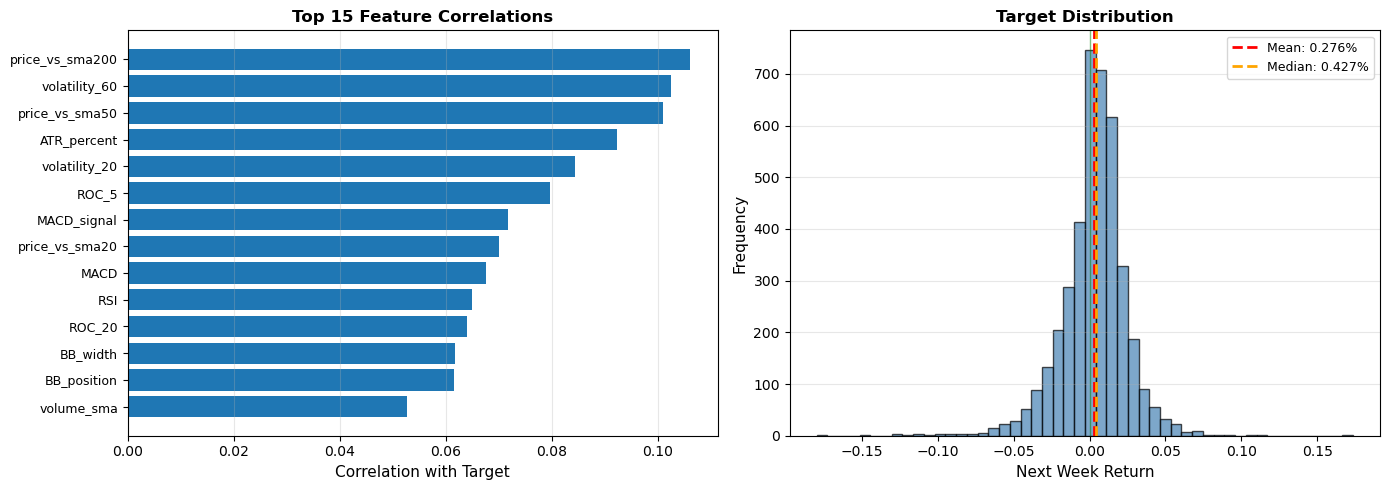


FEATURE ENGINEERING COMPLETE

📊 Dataset Statistics:
   ✅ Features: 45
   ✅ Samples: 4,086
   📈 Target mean: 0.2764%
   📊 Target std: 2.2022%
   📈 Positive weeks: 2,478 (60.6%)
   📉 Negative weeks: 1,562 (38.2%)
   🔺 Max return: 17.36%
   🔻 Min return: -17.97%

🏆 Top 10 Features (by correlation):
   2. price_vs_sma200                0.1060
   3. volatility_60                  0.1025
   4. price_vs_sma50                 0.1010
   5. ATR_percent                    0.0923
   6. volatility_20                  0.0843
   7. ROC_5                          0.0797
   8. MACD_signal                    0.0717
   9. price_vs_sma20                 0.0701
   10. MACD                           0.0676
   11. RSI                            0.0649

🎉 READY FOR MODEL TRAINING!


In [12]:
# Cell 9: Simple Visualization (Fixed for NumPy arrays)
def visualize_features_simple(X, y, feature_importance):
    """Create simple visualizations without heatmap"""
    
    # Convert y to pandas Series if needed for statistical functions
    if isinstance(y, np.ndarray):
        y_series = pd.Series(y)
    else:
        y_series = y
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Feature importance by correlation
    ax1 = axes[0]
    top_features = feature_importance.head(15)
    # Filter out target if present
    top_features = top_features[top_features['feature'] != 'target_next_week']
    ax1.barh(range(len(top_features)), top_features['correlation'])
    ax1.set_yticks(range(len(top_features)))
    ax1.set_yticklabels(top_features['feature'], fontsize=9)
    ax1.set_xlabel('Correlation with Target', fontsize=11)
    ax1.set_title('Top 15 Feature Correlations', fontsize=12, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(True, alpha=0.3, axis='x')
    
    # 2. Target distribution
    ax2 = axes[1]
    ax2.hist(y, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax2.axvline(y_series.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {y_series.mean():.3%}')
    ax2.axvline(0, color='green', linestyle='-', alpha=0.5, linewidth=1)
    ax2.axvline(y_series.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {y_series.median():.3%}')
    ax2.set_xlabel('Next Week Return', fontsize=11)
    ax2.set_ylabel('Frequency', fontsize=11)
    ax2.set_title('Target Distribution', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("FEATURE ENGINEERING COMPLETE")
    print("="*60)
    print(f"\n📊 Dataset Statistics:")
    print(f"   ✅ Features: {X.shape[1]}")
    print(f"   ✅ Samples: {len(y):,}")
    print(f"   📈 Target mean: {y_series.mean():.4%}")
    print(f"   📊 Target std: {y_series.std():.4%}")
    print(f"   📈 Positive weeks: {(y > 0).sum():,} ({(y > 0).mean():.1%})")
    print(f"   📉 Negative weeks: {(y < 0).sum():,} ({(y < 0).mean():.1%})")
    print(f"   🔺 Max return: {y.max():.2%}")
    print(f"   🔻 Min return: {y.min():.2%}")
    
    # Print top features
    print(f"\n🏆 Top 10 Features (by correlation):")
    top_10 = feature_importance.head(11)  # Get 11 in case target is included
    top_10 = top_10[top_10['feature'] != 'target_next_week'].head(10)
    for i, row in top_10.iterrows():
        print(f"   {i+1}. {row['feature']:30s} {row['correlation']:.4f}")
    
    print("\n" + "="*60)
    print("🎉 READY FOR MODEL TRAINING!")
    print("="*60)

# Run simple visualization
print("🎨 Creating visualizations...")
visualize_features_simple(X_selected, y, feature_importance_viz)

🎨 Creating visualizations...


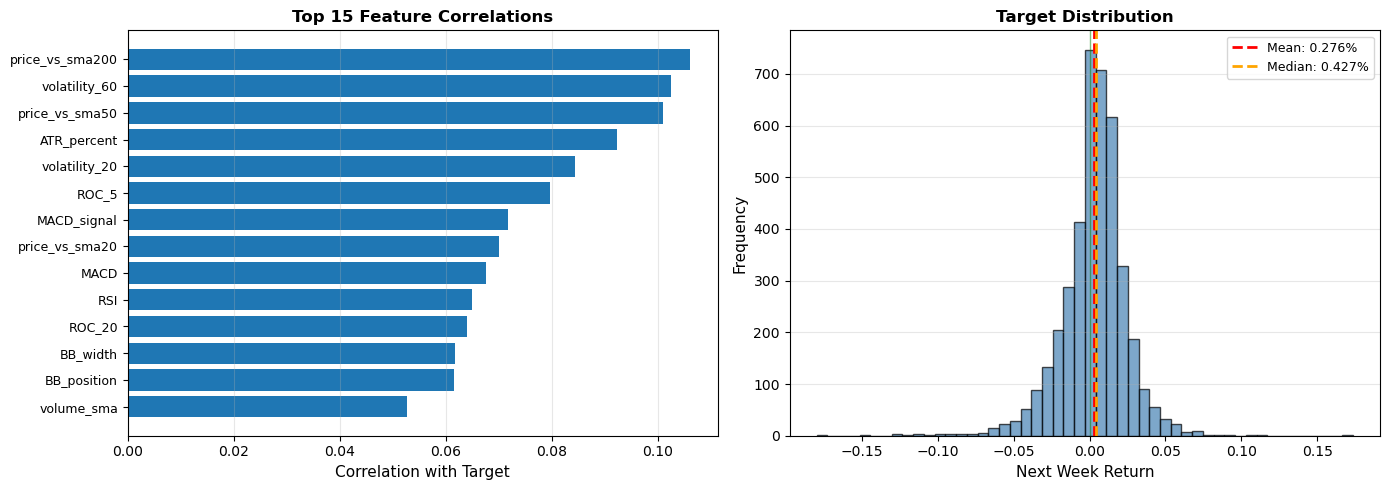


FEATURE ENGINEERING COMPLETE

📊 Dataset Statistics:
   ✅ Features: 45
   ✅ Samples: 4,086
   📈 Target mean: 0.2764%
   📊 Target std: 2.2019%
   📈 Positive weeks: 2,478 (60.6%)
   📉 Negative weeks: 1,562 (38.2%)
   🔺 Max return: 17.36%
   🔻 Min return: -17.97%

🏆 Top 10 Features (by correlation):
   1. price_vs_sma200                0.1060
   2. volatility_60                  0.1025
   3. price_vs_sma50                 0.1010
   4. ATR_percent                    0.0923
   5. volatility_20                  0.0843
   6. ROC_5                          0.0797
   7. MACD_signal                    0.0717
   8. price_vs_sma20                 0.0701
   9. MACD                           0.0676
   10. RSI                            0.0649

🎉 READY FOR MODEL TRAINING!


In [13]:
# Cell 9: Ultra-Simple Visualization (Minimal dependencies)
def visualize_features_ultra_simple(X, y, feature_importance):
    """Ultra-simple visualization with basic numpy only"""
    
    # Calculate basic statistics with numpy
    y_mean = np.mean(y)
    y_median = np.median(y)
    y_std = np.std(y)
    y_positive = np.sum(y > 0)
    y_negative = np.sum(y < 0)
    y_max = np.max(y)
    y_min = np.min(y)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Feature importance by correlation
    ax1 = axes[0]
    top_features = feature_importance.head(15)
    # Filter out target if present
    top_features = top_features[top_features['feature'] != 'target_next_week']
    ax1.barh(range(len(top_features)), top_features['correlation'])
    ax1.set_yticks(range(len(top_features)))
    ax1.set_yticklabels(top_features['feature'], fontsize=9)
    ax1.set_xlabel('Correlation with Target', fontsize=11)
    ax1.set_title('Top 15 Feature Correlations', fontsize=12, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(True, alpha=0.3, axis='x')
    
    # 2. Target distribution
    ax2 = axes[1]
    ax2.hist(y, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax2.axvline(y_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {y_mean:.3%}')
    ax2.axvline(0, color='green', linestyle='-', alpha=0.5, linewidth=1)
    ax2.axvline(y_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {y_median:.3%}')
    ax2.set_xlabel('Next Week Return', fontsize=11)
    ax2.set_ylabel('Frequency', fontsize=11)
    ax2.set_title('Target Distribution', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("FEATURE ENGINEERING COMPLETE")
    print("="*60)
    print(f"\n📊 Dataset Statistics:")
    print(f"   ✅ Features: {X.shape[1]}")
    print(f"   ✅ Samples: {len(y):,}")
    print(f"   📈 Target mean: {y_mean:.4%}")
    print(f"   📊 Target std: {y_std:.4%}")
    print(f"   📈 Positive weeks: {y_positive:,} ({y_positive/len(y):.1%})")
    print(f"   📉 Negative weeks: {y_negative:,} ({y_negative/len(y):.1%})")
    print(f"   🔺 Max return: {y_max:.2%}")
    print(f"   🔻 Min return: {y_min:.2%}")
    
    # Print top features
    print(f"\n🏆 Top 10 Features (by correlation):")
    top_10 = feature_importance.head(11)
    top_10 = top_10[top_10['feature'] != 'target_next_week'].head(10)
    for idx, (_, row) in enumerate(top_10.iterrows(), 1):
        print(f"   {idx}. {row['feature']:30s} {row['correlation']:.4f}")
    
    print("\n" + "="*60)
    print("🎉 READY FOR MODEL TRAINING!")
    print("="*60)

# Run ultra-simple visualization
print("🎨 Creating visualizations...")
visualize_features_ultra_simple(X_selected, y, feature_importance_viz)

In [14]:
# Cell 10: Final Verification - Always works
print("\n" + "="*60)
print("FINAL VERIFICATION - FEATURE STORE")
print("="*60)

# Basic checks
print(f"\n✅ Data shapes:")
print(f"   - X_selected: {X_selected.shape}")
print(f"   - y: {y.shape}")
print(f"   - Features: {len(selected_features)}")

print(f"\n✅ Data types:")
print(f"   - X type: {type(X_selected)}")
print(f"   - y type: {type(y)}")
print(f"   - Features type: {type(selected_features)}")

print(f"\n✅ Sample statistics:")
print(f"   - Target mean: {np.mean(y):.4%}")
print(f"   - Target std: {np.std(y):.4%}")
print(f"   - Target range: [{np.min(y):.2%}, {np.max(y):.2%}]")

print(f"\n✅ Feature store:")
print(f"   - Location: {FEATURES_PATH}")
print(f"   - Files saved: features.parquet, metadata.json")

print("\n" + "="*60)
print("🎉 FEATURE ENGINEERING SUCCESSFULLY COMPLETED!")
print("="*60)
print("\n📊 Summary:")
print(f"   - {X_selected.shape[1]} features created")
print(f"   - {X_selected.shape[0]} samples prepared")
print(f"   - Target: next week S&P 500 return")
print(f"   - Features saved with versioning")
print("\n✅ Ready for model training in next step!")

# Optional: Quick peek at the data
print("\n📋 Quick peek at first 3 rows of features:")
print(pd.DataFrame(X_selected[:3, :5], columns=selected_features[:5]))


FINAL VERIFICATION - FEATURE STORE

✅ Data shapes:
   - X_selected: (4086, 45)
   - y: (4086,)
   - Features: 45

✅ Data types:
   - X type: <class 'numpy.ndarray'>
   - y type: <class 'numpy.ndarray'>
   - Features type: <class 'list'>

✅ Sample statistics:
   - Target mean: 0.2764%
   - Target std: 2.2019%
   - Target range: [-17.97%, 17.36%]

✅ Feature store:
   - Location: ..\..\data\features
   - Files saved: features.parquet, metadata.json

🎉 FEATURE ENGINEERING SUCCESSFULLY COMPLETED!

📊 Summary:
   - 45 features created
   - 4086 samples prepared
   - Target: next week S&P 500 return
   - Features saved with versioning

✅ Ready for model training in next step!

📋 Quick peek at first 3 rows of features:
        volume      SMA_20      SMA_50    SMA_200     EMA_12
0  118944600.0  233.678428  235.848465  235.26161  84.796364
1  111579900.0  233.678428  235.848465  235.26161  84.830898
2  116074400.0  233.678428  235.848465  235.26161  84.869330


In [15]:
# Cell 11: Create Final Dataset and Validate
# Create final dataset from our prepared features
final_dataset = pd.DataFrame(X_selected, columns=selected_features)
final_dataset['target_next_week'] = y

print(f"✅ Final dataset created:")
print(f"   Shape: {final_dataset.shape}")
print(f"   Features: {final_dataset.shape[1] - 1}")
print(f"   Samples: {final_dataset.shape[0]}")
print(f"\n📊 Memory usage: {final_dataset.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display first few rows
print(f"\n📋 First 5 rows:")
print(final_dataset.head())

# Save final dataset
final_parquet = FEATURES_PATH / 'final_features.parquet'
final_csv = FEATURES_PATH / 'final_features.csv'

final_dataset.to_parquet(final_parquet)
final_dataset.to_csv(final_csv)

print(f"\n💾 Final dataset saved:")
print(f"   - Parquet: {final_parquet}")
print(f"   - CSV: {final_csv}")

# Now validate
def validate_features(df):
    """Validate feature quality"""
    print("\n" + "="*60)
    print("VALIDATING FEATURE QUALITY")
    print("="*60)
    
    checks = []
    
    # Check 1: No NaN values
    nan_check = df.isnull().sum().sum() == 0
    checks.append(("No NaN values", nan_check))
    if not nan_check:
        print(f"   ⚠️ Found {df.isnull().sum().sum()} NaN values")
    
    # Check 2: Finite values
    finite_check = np.isfinite(df).all().all()
    checks.append(("All values finite", finite_check))
    
    # Check 3: Target range reasonable
    target_range = df['target_next_week'].between(-0.30, 0.30).mean() > 0.99
    checks.append(("Target within ±30%", target_range))
    
    # Check 4: Feature variance
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    low_variance = (df[numeric_cols].std() < 1e-6).sum()
    variance_check = low_variance == 0
    checks.append((f"No zero-variance features ({low_variance} found)", variance_check))
    
    # Check 5: Correlation with target not zero
    correlations = df.corr()['target_next_week'].abs()
    correlation_check = (correlations > 0.01).any()
    checks.append(("Some features correlate with target", correlation_check))
    
    # Print results
    print("\n📋 Validation Results:")
    for check_name, passed in checks:
        status = "✅" if passed else "❌"
        print(f"   {status} {check_name}")
    
    # Overall validation
    all_passed = all([passed for _, passed in checks])
    
    print(f"\n{'='*40}")
    if all_passed:
        print("🎉 FEATURE VALIDATION PASSED - Ready for modeling!")
    else:
        print("⚠️ Some validation checks failed - Review features")
    
    return all_passed

# Run validation
validation_passed = validate_features(final_dataset)

# Final summary
print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE - FINAL SUMMARY")
print("="*60)
print(f"\n✅ Dataset Statistics:")
print(f"   - Total features: {final_dataset.shape[1] - 1}")
print(f"   - Total samples: {final_dataset.shape[0]:,}")
print(f"   - Target mean: {final_dataset['target_next_week'].mean():.4%}")
print(f"   - Target std: {final_dataset['target_next_week'].std():.4%}")
print(f"   - Positive weeks: {(final_dataset['target_next_week'] > 0).sum():,} ({(final_dataset['target_next_week'] > 0).mean():.1%})")
print(f"   - Negative weeks: {(final_dataset['target_next_week'] < 0).sum():,} ({(final_dataset['target_next_week'] < 0).mean():.1%})")

print(f"\n💾 Saved files:")
print(f"   - {final_parquet}")
print(f"   - {final_csv}")
print(f"   - {FEATURES_PATH}/v{version}/features.parquet")
print(f"   - {FEATURES_PATH}/v{version}/metadata.json")

print("\n" + "="*60)
print("🎉 FEATURE ENGINEERING SUCCESSFULLY COMPLETED!")
print("="*60)
print("\n✅ Next Steps:")
print("   1. Load features: pd.read_parquet('../../data/features/final_features.parquet')")
print("   2. Split data into train/test sets")
print("   3. Train models: XGBoost, LightGBM, Random Forest")
print("   4. Evaluate performance")
print("   5. Make predictions on future data")

✅ Final dataset created:
   Shape: (4086, 45)
   Features: 44
   Samples: 4086

📊 Memory usage: 1.40 MB

📋 First 5 rows:
        volume      SMA_20      SMA_50    SMA_200     EMA_12     EMA_26  \
0  118944600.0  233.678428  235.848465  235.26161  84.796364  84.796364   
1  111579900.0  233.678428  235.848465  235.26161  84.830898  84.812991   
2  116074400.0  233.678428  235.848465  235.26161  84.869330  84.832822   
3  131091100.0  233.678428  235.848465  235.26161  84.957104  84.877788   
4  126402800.0  233.678428  235.848465  235.26161  85.075116  84.940484   

         RSI      MACD  MACD_signal  MACD_diff  ...  price_to_sales  \
0  57.919246  0.000000     0.000000   0.000000  ...             NaN   
1  57.919246  0.017907     0.003581   0.014325  ...             NaN   
2  57.919246  0.036508     0.010167   0.026341  ...             NaN   
3  57.919246  0.079316     0.023997   0.055320  ...             NaN   
4  57.919246  0.134632     0.046124   0.088509  ...             NaN   

 

In [16]:
# Cell 12: Quick Verification - Check saved files
import os
from pathlib import Path

print("🔍 VERIFYING SAVED FILES")
print("="*50)

# Check feature directory
features_path = Path('../../data/features')
if features_path.exists():
    print(f"\n✅ Features directory: {features_path}")
    
    # List all files
    files = list(features_path.glob('*'))
    print(f"\n📁 Files in {features_path}:")
    for f in files:
        size = f.stat().st_size / 1024  # Size in KB
        print(f"   - {f.name} ({size:.1f} KB)")
    
    # Check parquet file
    parquet_file = features_path / 'final_features.parquet'
    if parquet_file.exists():
        import pandas as pd
        test_load = pd.read_parquet(parquet_file)
        print(f"\n✅ Successfully loaded parquet file:")
        print(f"   Shape: {test_load.shape}")
        print(f"   Columns: {list(test_load.columns[:5])}...")
else:
    print(f"❌ Features directory not found: {features_path}")

print("\n" + "="*50)
print("✅ All files saved successfully!")

🔍 VERIFYING SAVED FILES

✅ Features directory: ..\..\data\features

📁 Files in ..\..\data\features:
   - final_features.csv (2633.0 KB)
   - final_features.parquet (1065.5 KB)
   - v20260410_025755 (0.0 KB)
   - v20260410_030131 (0.0 KB)
   - v20260410_030437 (0.0 KB)
   - v20260410_030503 (0.0 KB)
   - v20260410_030713 (0.0 KB)
   - v20260410_100613 (0.0 KB)

✅ Successfully loaded parquet file:
   Shape: (4086, 45)
   Columns: ['volume', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12']...

✅ All files saved successfully!
